# Hospital readmission risk prediction

## Problem Statement
This project builds a predictive model to identify diabetic patients at high risk of 30-day readmission at discharge. Early identification would enable targeted interventions that improve patient outcomes, reduce preventable hospitalizations, and lower costs for hospitals and payers.
The project utilizes demographic data, clinical indicators, admission history, laboratory results, and medication-related features to build a robust predictive model.

## Data 
This dataset was obtained from UCI Machien learning repository. The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks.

https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008

## The project follows a structured ML pipeline, including:
1. Data Loading
2. Exploratory Data Analysis
4. Feature Engineering
5. Train/Test split
6. Regression Modeling
7. Hyperparameter tuning
8. Selecting best model
9. Model interpretation
10. Results
11. Save model

In [3]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore")
warnings.simplefilter("ignore", category=ConvergenceWarning)

## 1. Data Loading

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,RobustScaler, LabelEncoder, OrdinalEncoder, OneHotEncoder,PowerTransformer, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression,SGDClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
import time
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay

In [5]:
df = pd.read_csv('diabetic_data.csv')

## 2. Exploratory Data Analysis

In [6]:
df.info()

# Finding : Total 101766 rows and 50 features
# encounter_id and patient_nbr are identifier columns so can be dropped
# Target feature: readmitted

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [7]:
df = df.drop(['encounter_id','patient_nbr'],axis = 1)

In [8]:
df.isnull().sum()

race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide                   0
glipizide                       0
glyburide     

In [9]:
df.describe()

#Finding
# High chance of outliers for num_medications,number_outpatient, number_outpatient,number_inpatient - will have to further look into these features

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


### Univariate Analysis

In [10]:
#Checking target column
df['readmitted'].value_counts()

#Finding 
# We have 3 categories for days to inpatient readmission. 
# Values: <30 if the patient was readmitted in less than 30 days, 
# >30 if the patient was readmitted in more than 30 days, 
# No for no record of readmission.
# As seen data is for readmissions within 30 days is only 11% making this dataset very imbalanced

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

<Axes: ylabel='count'>

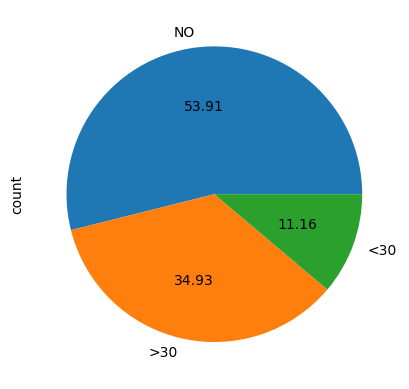

In [11]:
df['readmitted'].value_counts().plot(kind='pie', autopct='%.2f')

In [12]:
#get all numerical columns
num_cols = df.select_dtypes(include=['number']).columns.tolist()
len(num_cols)

11

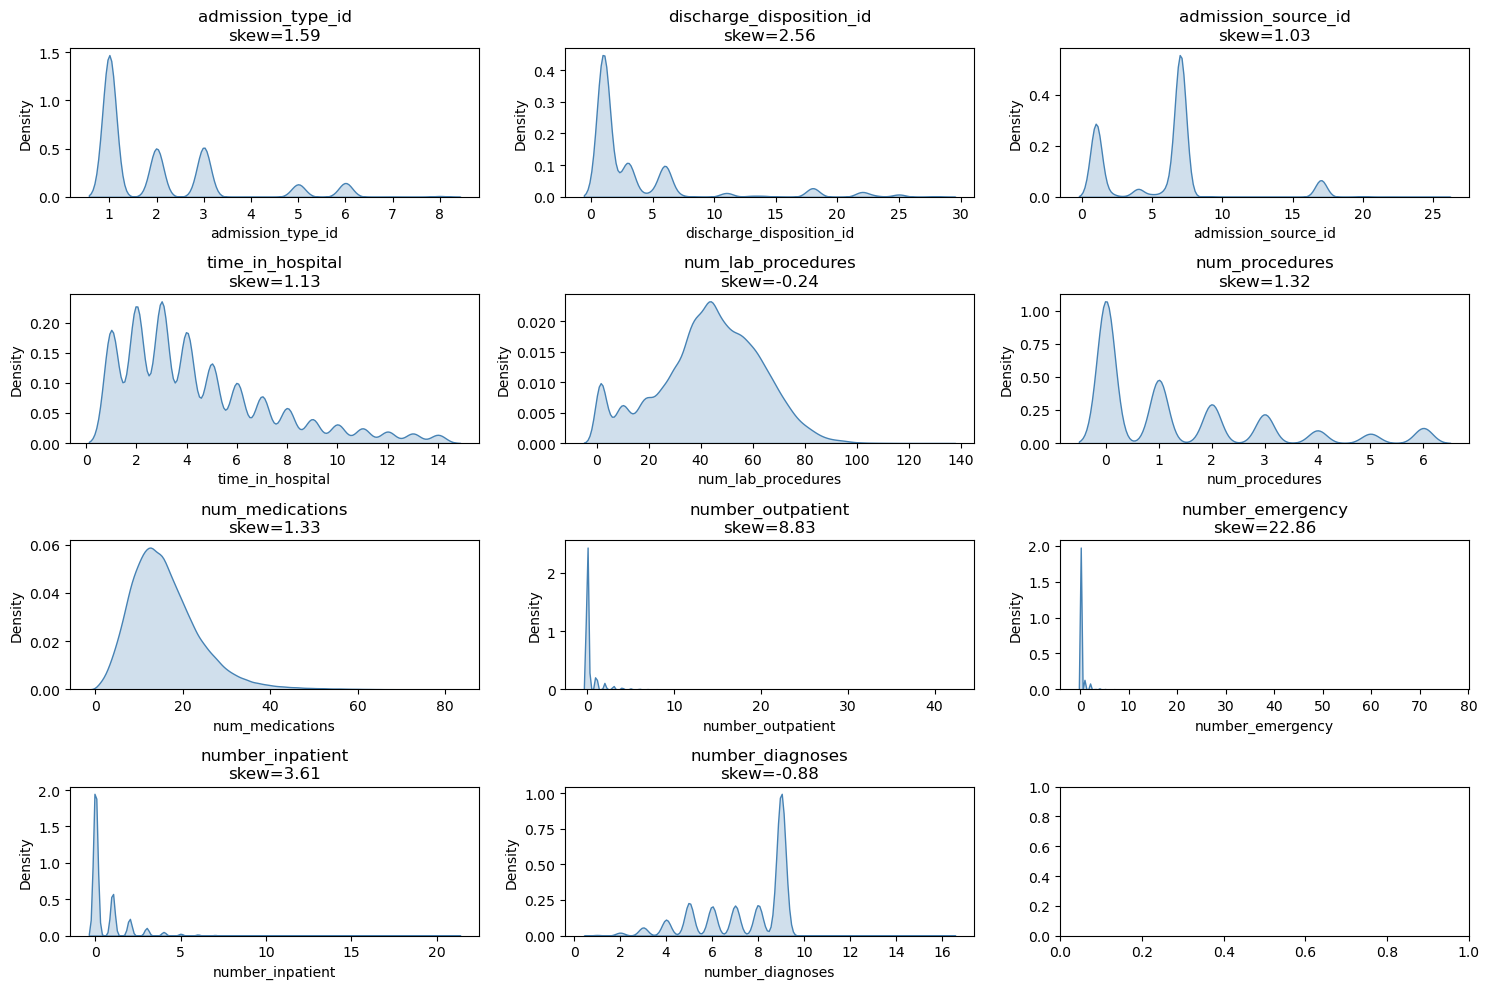

In [13]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.kdeplot(df[col], ax=axes[i], fill=True, color='steelblue')
    axes[i].set_title(f'{col}\nskew={df[col].skew():.2f}')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

#Finding - 
# All of the ID columns in data are categorical columns which explains.


In [14]:
df['admission_type_id'].value_counts()


admission_type_id
1    53990
3    18869
2    18480
6     5291
5     4785
8      320
7       21
4       10
Name: count, dtype: int64

In [15]:
#Per documentation : Mapping for admission_type_id -
# 1	Emergency
# 2	Urgent
# 3	Elective
# 4	Newborn
# 5	Not Available
# 6	NULL
# 7	Trauma Center
# 8	Not Mapped

# As can be seen 6,5,8 can be treated as missing values. 

# discharge_disposition_id has values - 18, 25, 26 corresponding to missing values. These can be grouped to reduce cardinality

# admission_source_id - 
# Values - 9,15 are "Not Available"
# 17 - NULL , 20 - Not Mapped, 21 - Unknown/Invalid

#Data cleaning is required for these columns

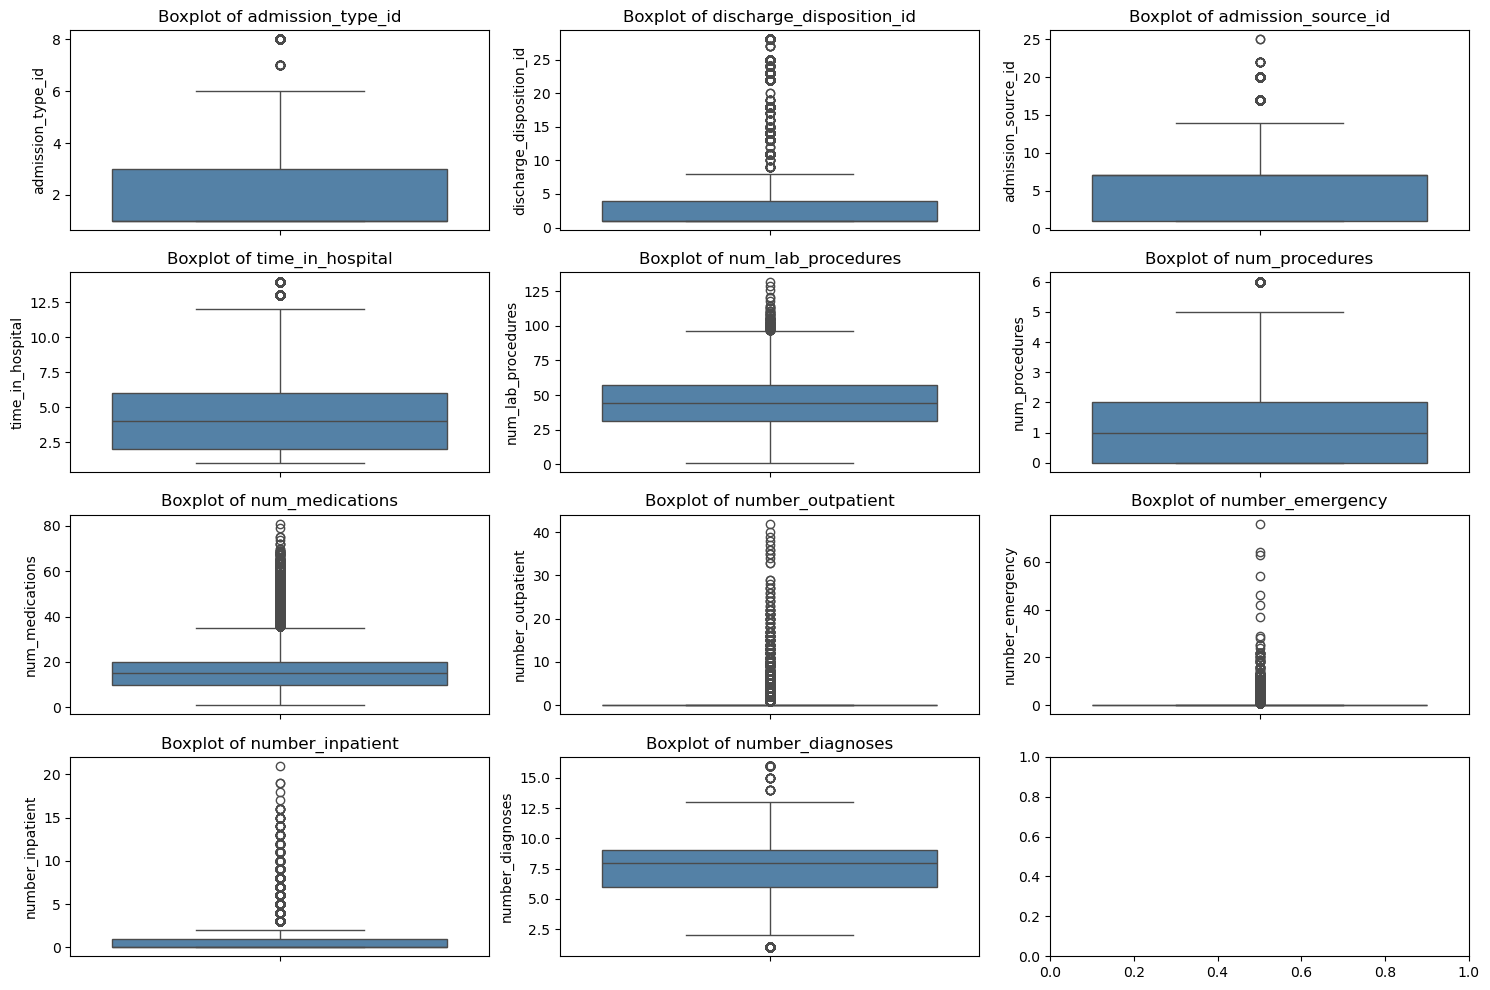

In [16]:
#Box plot to better visualize outliers

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

#Finding - 
# number_emergency, number_outpatient,number_inpatient - IQR is at 0. Outlier removal could be performed on these columns

In [17]:
df['num_medications'].value_counts()

num_medications
13    6086
12    6004
11    5795
15    5792
14    5707
      ... 
70       2
75       2
81       1
79       1
74       1
Name: count, Length: 75, dtype: int64

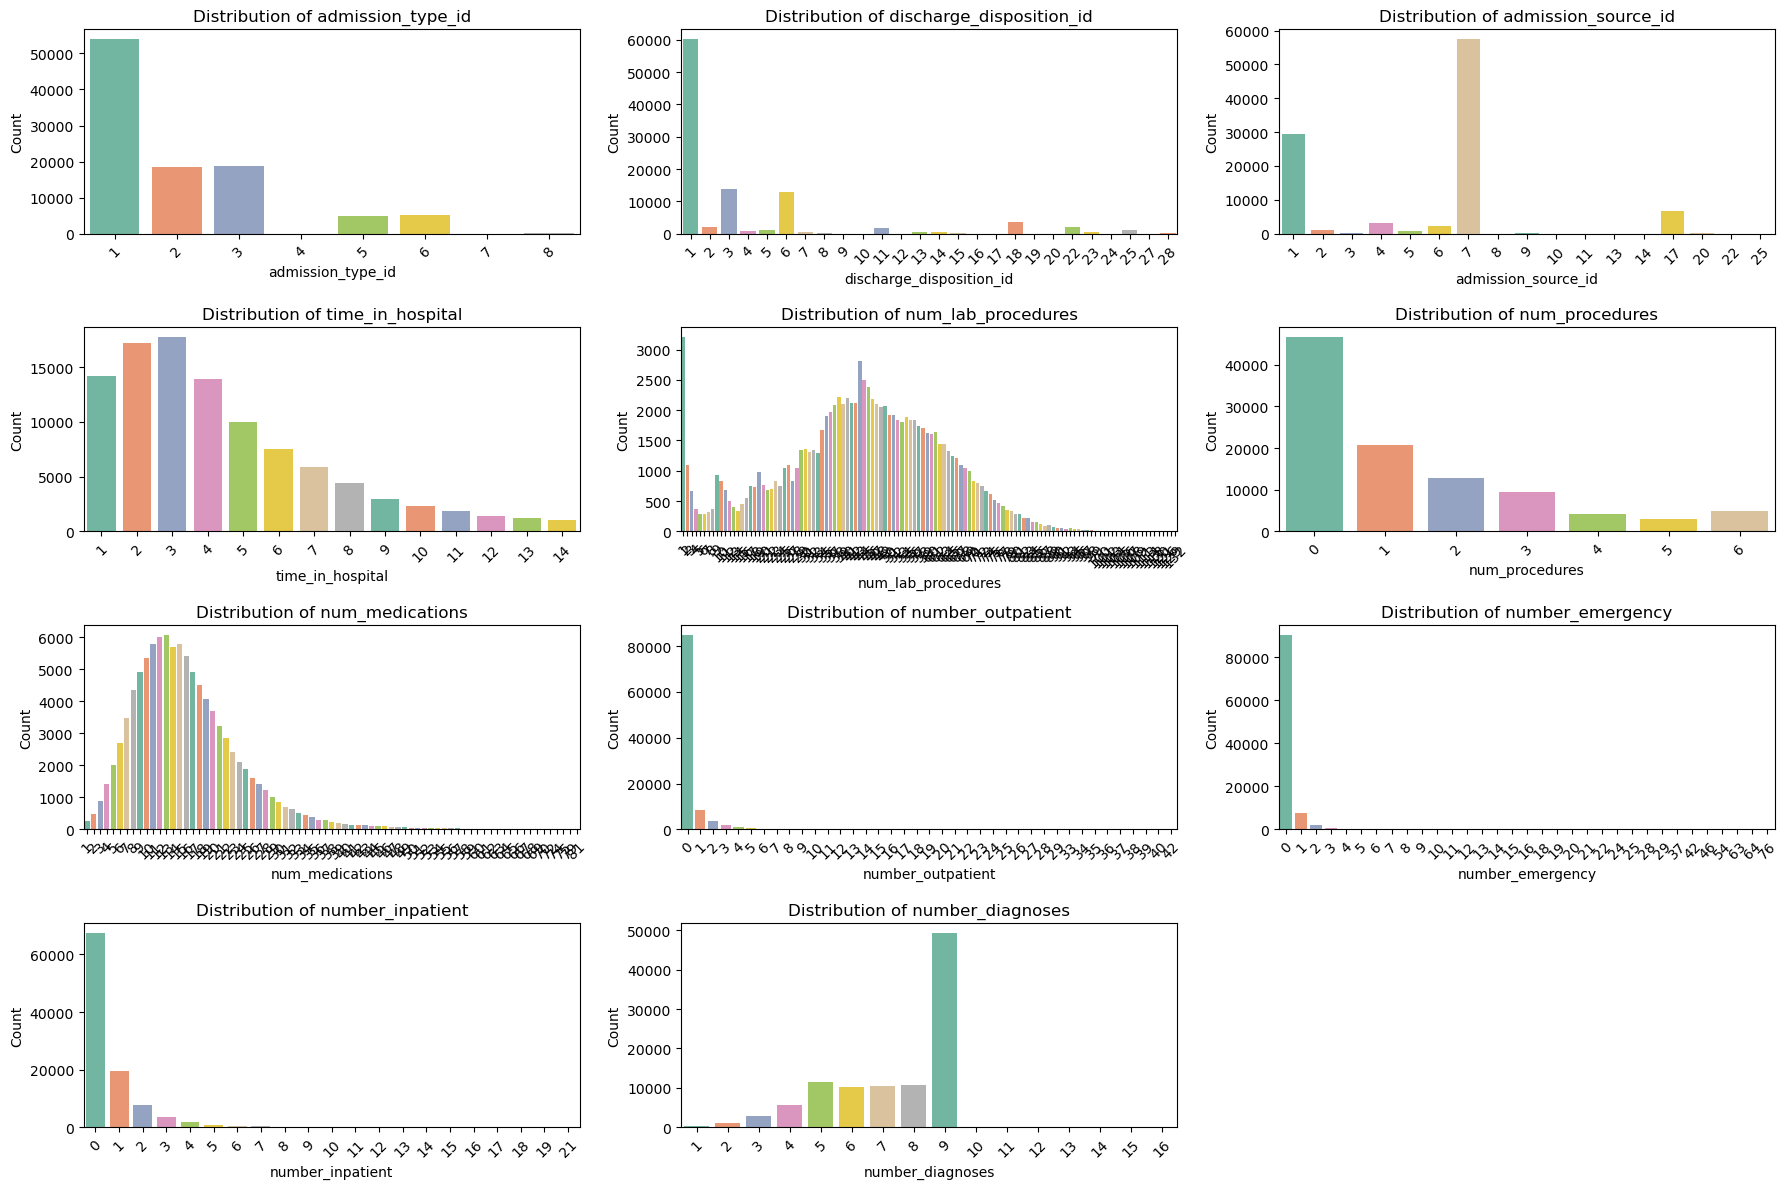

In [18]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette='Set2', hue=col, legend=False)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#Finding
# most of the patients have no outpatient, emergency and in-patients visits over the past year preceding the encounter.
# admission_source_id - most of the patients in the dataset were either referred by a physician(1) or came from emergency room(7)
# high number of patients were discharged to home (1). The next higher amounts where transferred to SNF(3) or home with health services(6)
# Indicating that these were not critical patients
# however, their admission types were mostly emergency (1) and urgent (2) or elective(3).
# number of lab procedures required for the patients averaged to around 43, whereas average time spent in the hospital was around 4 hours,
#discharge_disposition_id - Codes 11, 13, 14, 19, 20, 21 are either expired or in hospice, we can drop these since they can never be readmitted, adding bias to negative class.

### Bivariate for numerical columns with target column 

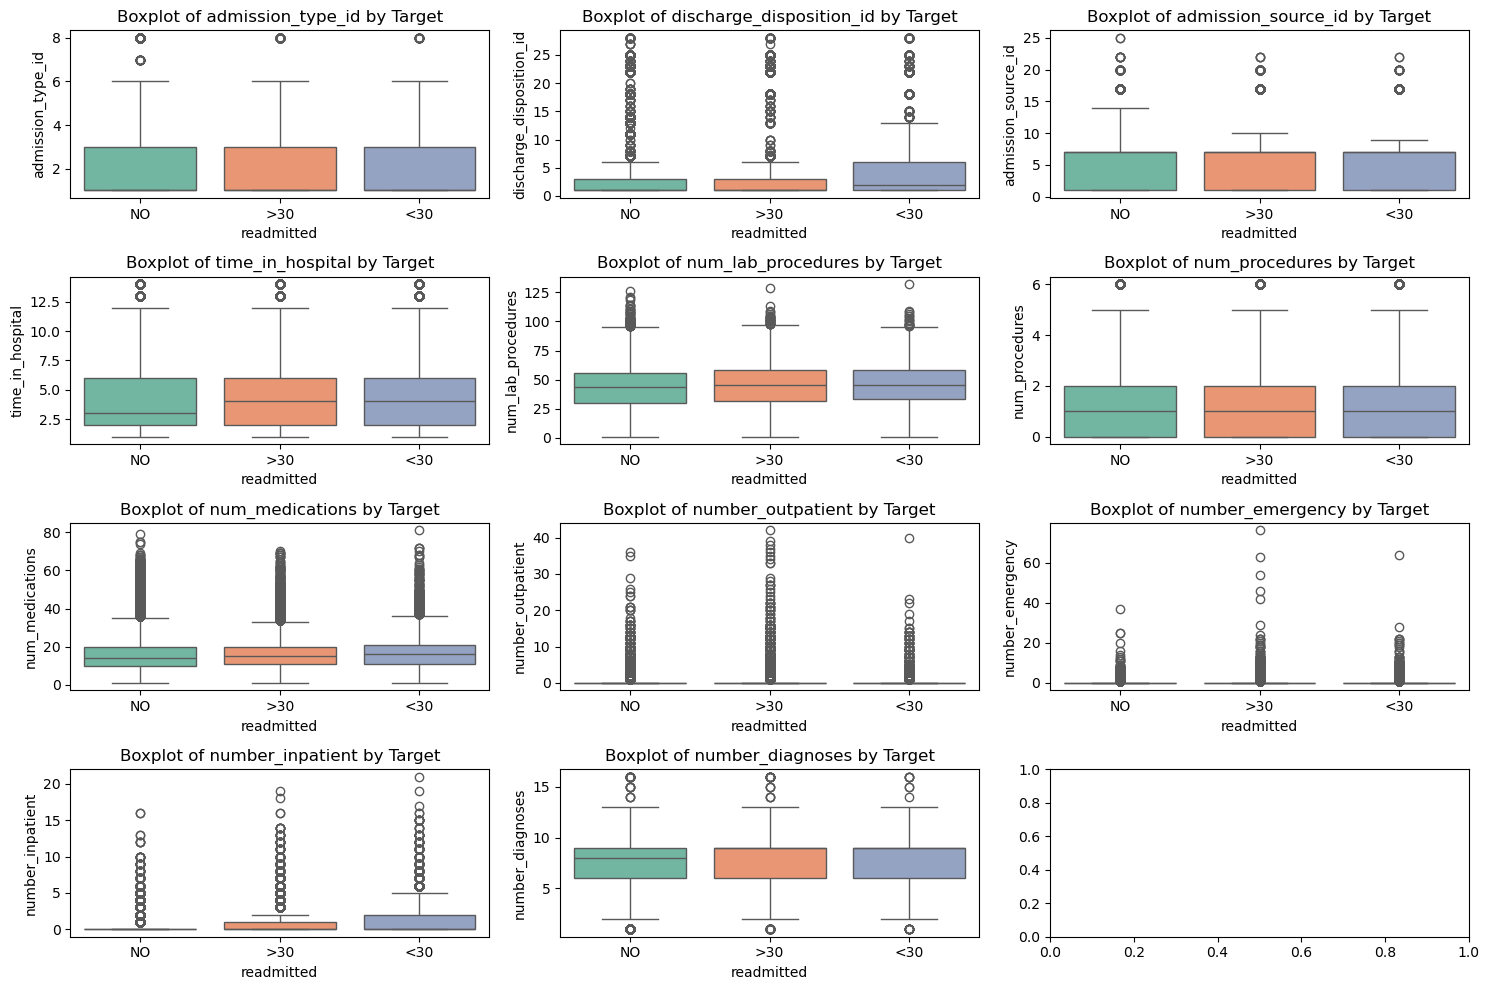

In [19]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='readmitted', y=col, ax=axes[i], palette='Set2', hue='readmitted')
    axes[i].set_title(f'Boxplot of {col} by Target')

plt.tight_layout()
plt.show()


In [20]:
# Univariate - Categorical Variables 
print("Descriptive statistics of categorical variables:")
df.describe(include=['object', 'category'])

# Data cleaning for age since values are in a range
# transformation is needed for age, gender, race and medicine columns
# cleaning is needed for columns with ? 
# high cardinality on diag, medical specialty,payer_code columns - Diag and medical specialty columns will need to be grouped before encoding

Descriptive statistics of categorical variables:


,race,gender,age,weight,payer_code,medical_specialty,diag_1,diag_2,diag_3,max_glu_serum,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
count,101766,101766,101766,101766,101766,101766,101766,101766,101766,5346,...,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766
unique,6,3,10,10,18,73,717,749,790,3,...,1,4,4,2,2,2,2,2,2,3
top,Caucasian,Female,[70-80),?,?,?,428,276,250,Norm,...,No,No,No,No,No,No,No,No,Yes,NO
freq,76099,54708,26068,98569,40256,49949,6862,6752,11555,2597,...,101766,47383,101060,101753,101765,101764,101765,54755,78363,54864


In [21]:
df['diag_1'].value_counts()


diag_1
428    6862
414    6581
786    4016
410    3614
486    3508
       ... 
373       1
314       1
684       1
217       1
V51       1
Name: count, Length: 717, dtype: int64

In [22]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(cat_cols)

['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


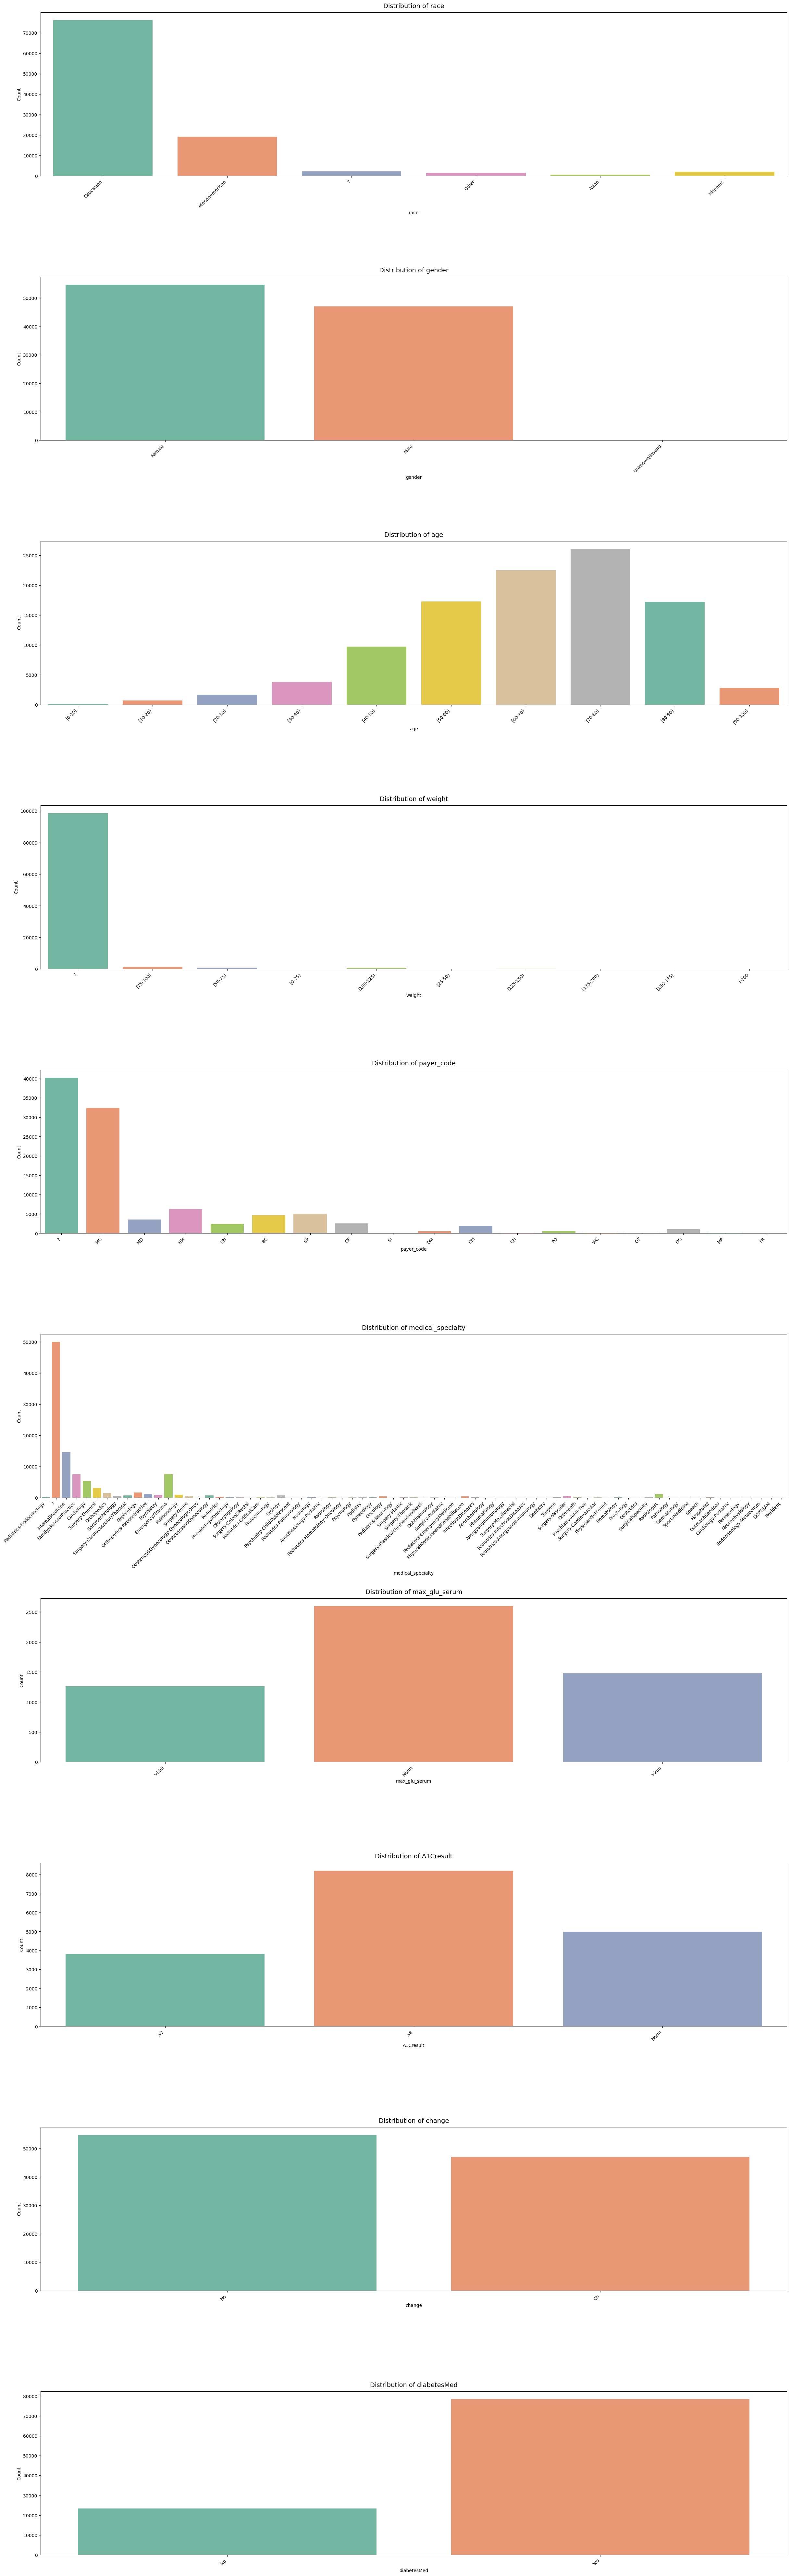

In [23]:
# Non medication columns
non_med_cols = ['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty','max_glu_serum', 'A1Cresult','change', 'diabetesMed']
fig, axes = plt.subplots(10, 1, figsize=(25, 80))  

for i, col in enumerate(non_med_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette='Set2', hue=col, legend=False)
    axes[i].set_title(f'Distribution of {col}', fontsize=14, pad=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xticklabels(
        axes[i].get_xticklabels(), 
        rotation=45, 
        ha='right'      
    )

plt.tight_layout(pad=3.0) 
plt.show()

# Weight column has mostly ? (NaN) so it can be dropped
# Unknown gender rows can be dropped
# Medical specialty will need cleaning as well as mostly a few categories have most of hte data

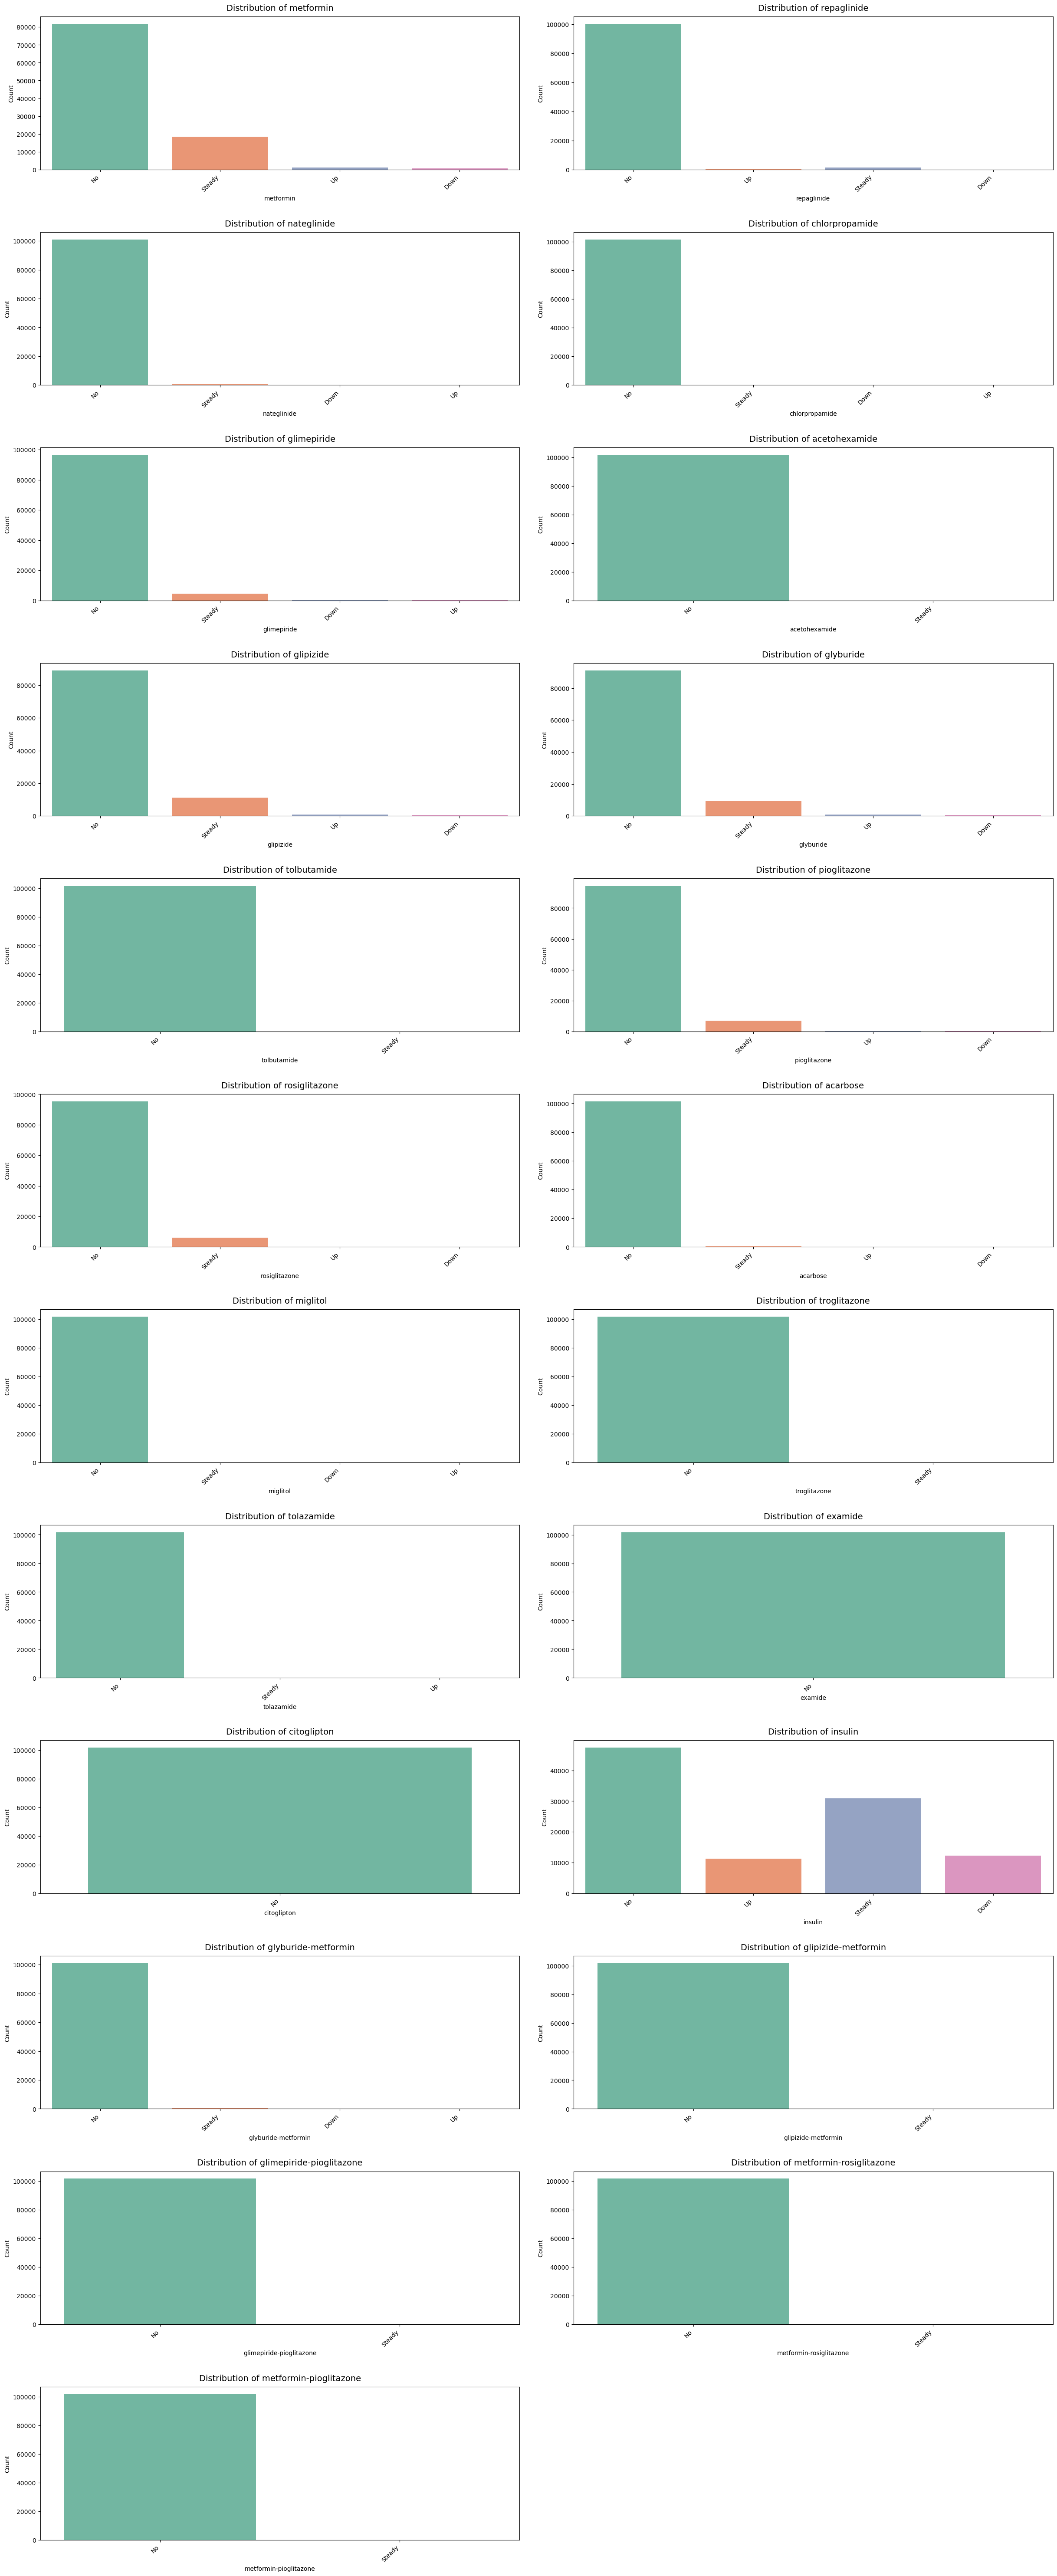

In [24]:
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']

n_cols = 2
n_rows = 12

fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, n_rows * 5))  
axes = axes.flatten() 

for i, col in enumerate(med_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette='Set2', hue=col, legend=False)
    axes[i].set_title(f'Distribution of {col}', fontsize=14, pad=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')

# Hide the unused last subplot (23 is odd, so one cell is empty)
for j in range(len(med_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(pad=3.0)
plt.show()


### Bivariate analysis of categorical columns 

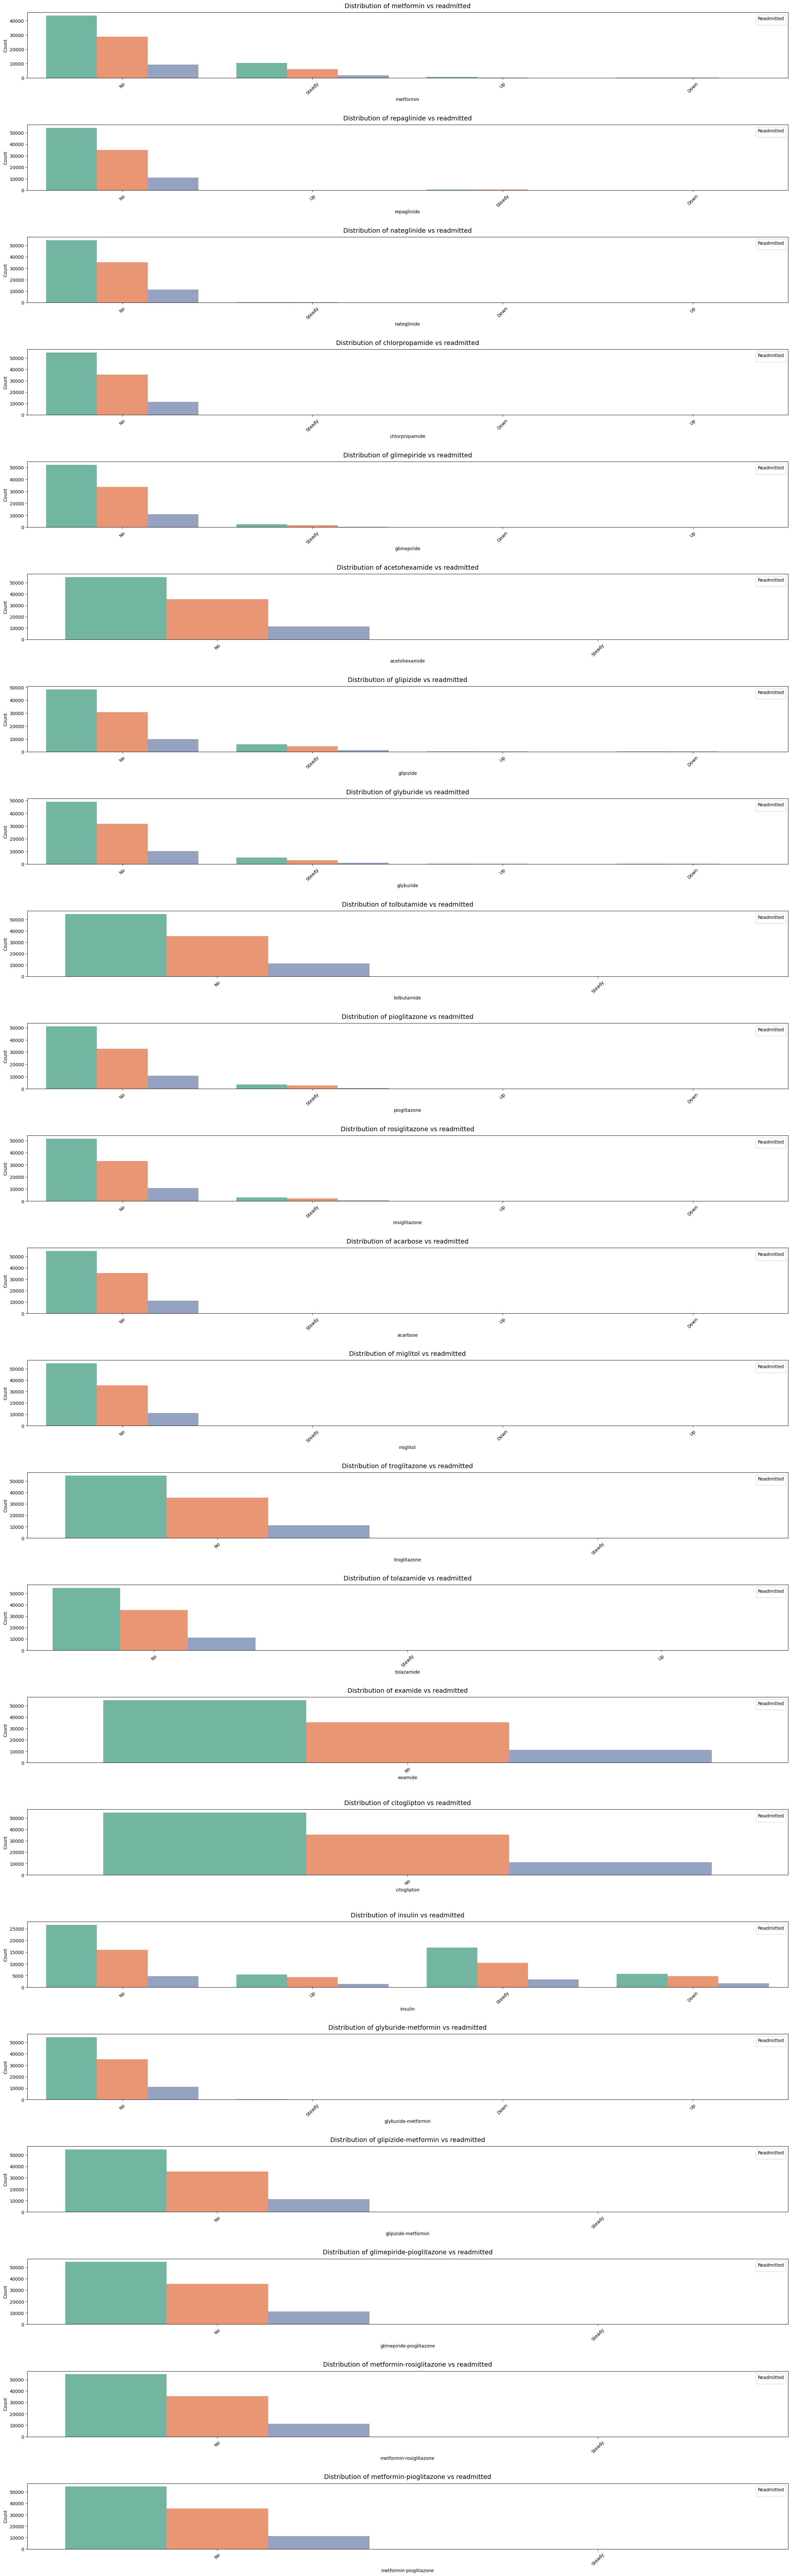

In [25]:
#Plotting medicines vs target column
#fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 14))
fig, axes = plt.subplots(23, 1, figsize=(25, 80)) 

for i, col in enumerate(med_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette='Set2', hue='readmitted', legend=False)
    axes[i].set_title(f'Distribution of {col} vs readmitted', fontsize=14, pad=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Readmitted', loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xticklabels(
        axes[i].get_xticklabels(), 
        rotation=45, 
    )

plt.tight_layout(pad=3.0) 
plt.show()
#Finding -
# acetohexamide,examide, citoglipton

In [26]:
modal_share = {c: df[c].value_counts(normalize=True).max() for c in med_cols}
informative_meds = [c for c, p in modal_share.items() if p < 0.99]
informative_meds

#Medicines <.99 have mostly values in No. These can be dropped. We will be analysing below ones

['metformin',
 'repaglinide',
 'glimepiride',
 'glipizide',
 'glyburide',
 'pioglitazone',
 'rosiglitazone',
 'insulin']

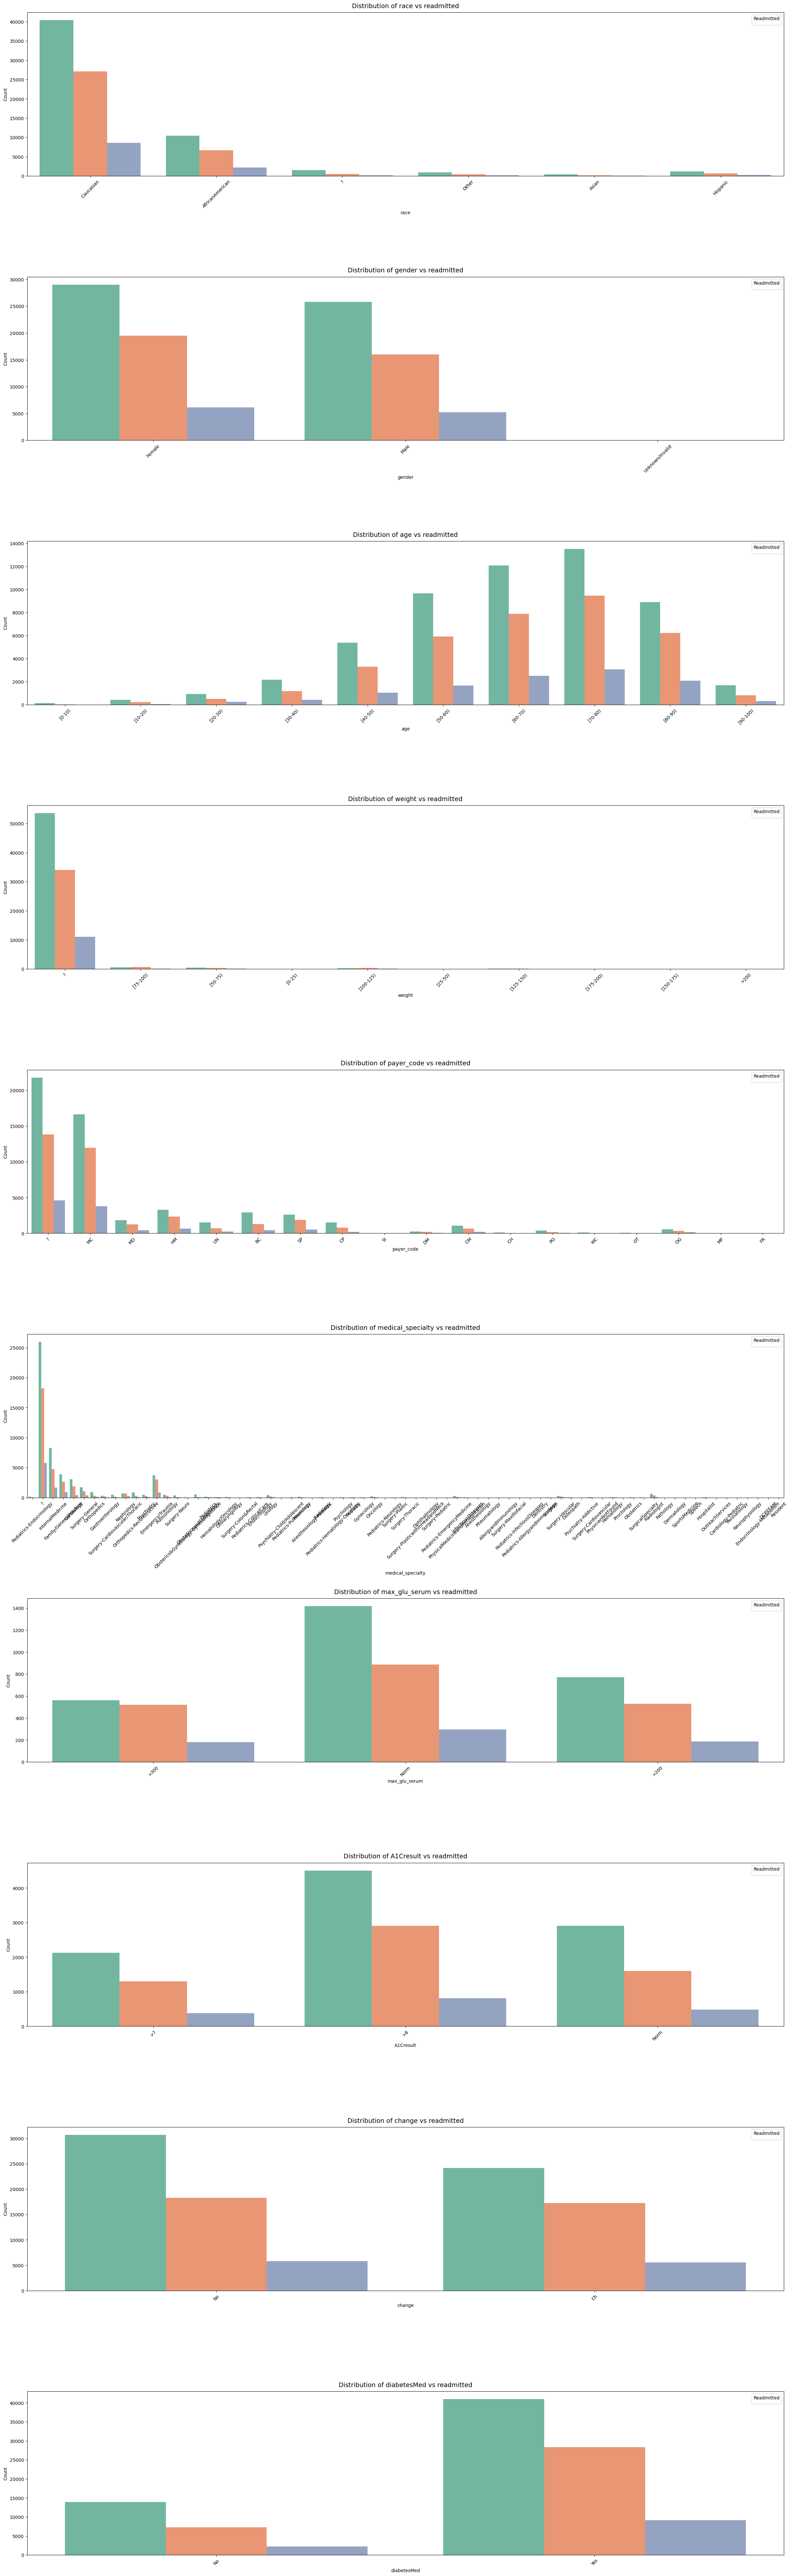

In [27]:
#Plotting non med cols vs target column
fig, axes = plt.subplots(nrows=10, ncols=1, figsize=(25, 80)) 

for i, col in enumerate(non_med_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette='Set2', hue='readmitted', legend=False)
    axes[i].set_title(f'Distribution of {col} vs readmitted', fontsize=14, pad=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Readmitted', loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xticklabels(
        axes[i].get_xticklabels(), 
        rotation=45, 
    )

plt.tight_layout(pad=3.0) 
plt.show()


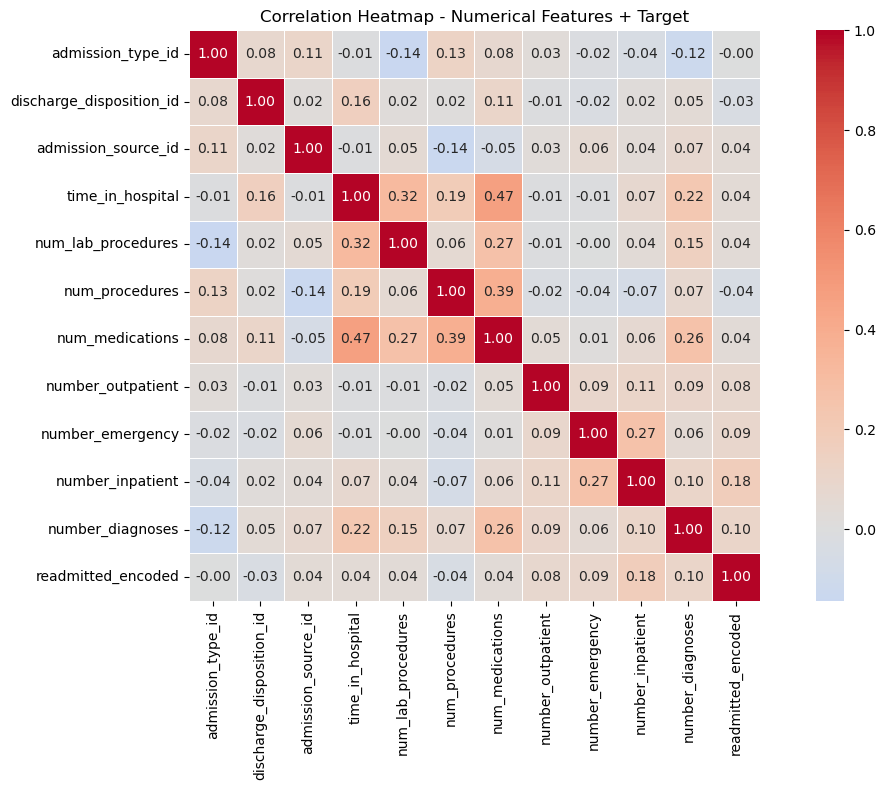

In [28]:
# correlation between numerical features and target column
df['readmitted_encoded'] = df['readmitted'].map({'>30': 2, '<30': 1, 'NO':0})
# Include encoded target in correlation
numerical_df = df.select_dtypes(include='number').copy()
numerical_df

corr_matrix = numerical_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Correlation Heatmap - Numerical Features + Target')
plt.tight_layout()
plt.show()

In [29]:
df = df.drop('readmitted_encoded',axis=1)

In [37]:
from scipy.stats import chi2_contingency
import numpy as np

cat_col = informative_meds+non_med_cols

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2, p, _, _ = chi2_contingency(ct)
    n = ct.values.sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1))), p

results = pd.DataFrame(
    [(c, *cramers_v(df[c], df['readmitted'])) for c in cat_col],
    columns=['med','cramers_v','p_value']
).sort_values('cramers_v', ascending=False)

In [38]:
results
#As seen medical_speciality, diabetersMed,payer_code,insulin,max_glu_serum seem to be associated with readmissions risk
# the rest of the medications have a weak correlation to readmissions.


,med,cramers_v,p_value
13,medical_specialty,0.081580,9.213296e-196
17,diabetesMed,0.061628,1.175514e-84
14,max_glu_serum,0.057304,4.409656e-07
12,payer_code,0.050602,1.559345e-88
7,insulin,0.050385,2.126586e-108
16,change,0.046052,1.362061e-47
10,age,0.039226,9.348415e-56
8,race,0.037262,7.379469e-55
11,weight,0.035985,1.407329e-45
0,metformin,0.022696,2.445917e-20


## Feature Engineering

In [ ]:
#Dropping columns discovered in EDA that are not needed in analysis
df = df.drop(['weight','glyburide','glimepiride','nateglinide', 'chlorpropamide','acetohexamide', 'nateglinide','tolbutamide', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone'],axis = 1)


In [ ]:
df.info()

In [ ]:
# Fixing admission_type_id, discharge_disposition_id,admission_source_id - cleaning and converting to categorical columns

discharge_disposition_map = {
    1: 'Discharged to home',
    2: 'Discharged/transferred to another short term hospital',
    3: 'Discharged/transferred to SNF',
    4: 'Discharged/transferred to ICF',
    5: 'Discharged/transferred to another type of inpatient care institution',
    6: 'Discharged/transferred to home with home health service',
    7: 'Left AMA',
    8: 'Discharged/transferred to home under care of Home IV provider',
    9: 'Admitted as an inpatient to this hospital',
    10: 'Neonate discharged to another hospital for neonatal aftercare',
    11: 'Expired',
    12: 'Still patient or expected to return for outpatient services',
    13: 'Hospice / home',
    14: 'Hospice / medical facility',
    15: 'Discharged/transferred within this institution to Medicare approved swing bed',
    16: 'Discharged/transferred/referred another institution for outpatient services',
    17: 'Discharged/transferred/referred to this institution for outpatient services',
    18: 'NULL',
    19: 'Expired at home. Medicaid only, hospice.',
    20: 'Expired in a medical facility. Medicaid only, hospice.',
    21: 'Expired, place unknown. Medicaid only, hospice.',
    22: 'Discharged/transferred to another rehab fac including rehab units of a hospital',
    23: 'Discharged/transferred to a long term care hospital',
    24: 'Discharged/transferred to a nursing facility certified under Medicaid but not Medicare',
    25: 'Not Mapped',
    26: 'Unknown/Invalid',
    30: 'Discharged/transferred to another Type of Health Care Institution not Defined Elsewhere',
    27: 'Discharged/transferred to a federal health care facility',
    28: 'Discharged/transferred/referred to a psychiatric hospital',
    29: 'Discharged/transferred to a Critical Access Hospital (CAH)'
}

admission_source_map = {
    1: 'Physician Referral',
    2: 'Clinic Referral',
    3: 'HMO Referral',
    4: 'Transfer from a hospital',
    5: 'Transfer from a Skilled Nursing Facility',
    6: 'Transfer from another health care facility',
    7: 'Emergency Room',
    8: 'Court/Law Enforcement',
    9: 'Not Available',
    10: 'Transfer from critial access hospital',
    11: 'Normal Delivery',
    12: 'Premature Delivery',
    13: 'Sick Baby',
    14: 'Extramural Birth',
    15: 'Not Available',
    17: 'NULL',
    18: 'Transfer From Another Home Health Agency',
    19: 'Readmission to Same Home Health Agency',
    20: 'Not Mapped',
    21: 'Unknown/Invalid',
    22: 'Transfer from hospital inpt/same fac reslt in a sep claim',
    23: 'Born inside this hospital',
    24: 'Born outside this hospital',
    25: 'Transfer from Ambulatory Surgery Center',
    26: 'Transfer from Hospice'
}

admission_type_map = {
    1: 'Emergency',
    2: 'Urgent',
    3: 'Elective',
    4: 'Newborn',
    5: 'Not Available',
    6: 'NULL',
    7: 'Trauma Center',
    8: 'Not Mapped'
}

# Apply all three at once
id_mappings = {
    'admission_type_id': admission_type_map,
    'discharge_disposition_id': discharge_disposition_map,
    'admission_source_id': admission_source_map
}

for col, mapping in id_mappings.items():
    df[col] = df[col].map(mapping)

In [ ]:
null_values = {'NULL', 'Not Available', 'Not Mapped', 'Unknown/Invalid'}

for col in id_mappings.keys():
    df[col] = df[col].replace(null_values, np.nan)

In [ ]:
#dropping "Expired" rows in discharge_disposition_id since these patients cannot be readmitted and they create bias to negative class.(NO)
expired_labels = [
    'Expired',
    'Expired at home. Medicaid only, hospice.',
    'Expired in a medical facility. Medicaid only, hospice.',
    'Expired, place unknown. Medicaid only, hospice.'
]

df = df[~df['discharge_disposition_id'].isin(expired_labels)].reset_index(drop=True)

In [ ]:
#Handling '?' values across columns
df.replace('?', np.nan, inplace=True)

In [ ]:
df.isnull().sum()

In [ ]:
#Handling diag1,2,3 columns as they have 700+ different categories - https://www.aapc.com/codes/icd9-codes-range/

def map_icd9_to_category(code):
    if pd.isnull(code):
        return 'Unknown'
    
    code = str(code).strip()
    
    # Special codes (non-numeric prefixes)
    if code.startswith('V'):
        return 'Supplementary'
    if code.startswith('E'):
        return 'External Causes'
    
    try:
        code_num = float(code)
    except ValueError:
        return 'Unknown'

    if 390 <= code_num <= 459:
        return 'Circulatory'
    elif 460 <= code_num <= 519:
        return 'Respiratory'
    elif 520 <= code_num <= 579:
        return 'Digestive'
    elif code_num == 250:
        return 'Diabetes'
    elif 800 <= code_num <= 999:
        return 'Injury'
    elif 710 <= code_num <= 739:
        return 'Musculoskeletal'
    elif 580 <= code_num <= 629:
        return 'Genitourinary'
    elif 140 <= code_num <= 239:
        return 'Neoplasms'
    elif 1 <= code_num <= 139:
        return 'Infectious'
    elif 240 <= code_num <= 249 or 251 <= code_num <= 279:
        return 'Endocrine/Metabolic'
    elif 280 <= code_num <= 289:
        return 'Blood'
    elif 290 <= code_num <= 319:
        return 'Mental'
    elif 320 <= code_num <= 389:
        return 'Nervous System'
    elif 630 <= code_num <= 679:
        return 'Pregnancy'
    elif 680 <= code_num <= 709 or code_num == 782:
        return 'Skin'
    elif 740 <= code_num <= 759:
        return 'Congenital'
    elif 760 <= code_num <= 779:
        return 'Perinatal'
    elif 780 <= code_num <= 799:
        return 'Symptoms/Ill-defined'
    else:
        return 'Other'

# Apply to all three diagnosis columns
for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].apply(map_icd9_to_category)

In [ ]:
df['medical_specialty'].unique()

In [ ]:
# grouping medical_specialty since there are 
def map_medical_specialty(spec):
    if pd.isnull(spec):
        return 'Unknown'
    
    spec = str(spec).strip()
    
    if 'Intern' in spec or 'Family' in spec or 'General' in spec:
        return 'General Practice'
    elif 'Cardio' in spec:
        return 'Cardiology'
    elif 'Surg' in spec:
        return 'Surgery'
    elif 'Endocrin' in spec or 'Metabolism' in spec:
        return 'Endocrinology'
    elif 'Nephro' in spec:
        return 'Nephrology'
    elif 'Neuro' in spec:
        return 'Neurology'
    elif 'Gastro' in spec or 'Hepato' in spec:
        return 'Gastroenterology'
    elif 'Pulmo' in spec or 'Thoracic' in spec or 'Respiratory' in spec:
        return 'Pulmonology'
    elif 'Ortho' in spec:
        return 'Orthopedics'
    elif 'Onco' in spec or 'Radiat' in spec:
        return 'Oncology'
    elif 'Psych' in spec:
        return 'Psychiatry'
    elif 'Obst' in spec or 'Gynec' in spec:
        return 'OB/GYN'
    elif 'Pedia' in spec:
        return 'Pediatrics'
    elif 'Urolog' in spec:
        return 'Urology'
    elif 'Ophthal' in spec:
        return 'Ophthalmology'
    elif 'Hematol' in spec:
        return 'Hematology'
    elif 'Infect' in spec:
        return 'Infectious Disease'
    elif 'Emergency' in spec or 'Trauma' in spec:
        return 'Emergency'
    elif 'Rehab' in spec or 'Physical' in spec:
        return 'Rehabilitation'
    elif 'Anesthesio' in spec:
        return 'Anesthesiology'
    elif 'Radiol' in spec or 'Diagnostic' in spec:
        return 'Radiology'
    else:
        return 'Other'

df['medical_specialty'] = df['medical_specialty'].apply(map_medical_specialty)

In [ ]:
df['medical_specialty'].unique()

In [ ]:
df

In [31]:
df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)

X = df.drop(columns=['readmitted', 'readmitted_30'])
y = df['readmitted_30']

ord_cols = ['age']

num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()
cat_cols.remove('age')

print("num_cols:", num_cols)
print("cat_cols:", cat_cols)
print("ord_cols:", ord_cols)


# Pipelines
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)',
             '[60-70)', '[70-80)', '[80-90)', '[90-100)']

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
ord_pipe = Pipeline([
    ('encoder', OrdinalEncoder(categories=[age_order]))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols),
    ('ord', ord_pipe, ord_cols),
])

num_cols: ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
cat_cols: ['race', 'gender', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']
ord_cols: ['age']


In [32]:
# Train/test split & fit 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [33]:
#Function to find scoring for baseline models with default params
def getBaselineModelStats(models,preprocessor):
    results_score = []
    for name, model in models.items():
        # Create a pipeline
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            (name, model)
        ])

         # Fit the model and time it
        start_time = time.time()
        pipeline.fit(X_train, y_train)
        fit_time = time.time() - start_time
    
        # Evaluate on training and test sets
        train_score = pipeline.score(X_train, y_train)
        test_score = pipeline.score(X_test, y_test)
    
        
        y_pred = pipeline.predict(X_test)

        results_score.append({
            "Model": name,
            "Train time": fit_time,
            "Train accuracy": train_score,
            "Test accuracy": test_score,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1 Score": f1_score(y_test, y_pred)
        })
        
    return (results_score)

In [34]:
default_models = {
    'logisticRegression': (LogisticRegression(max_iter=1000)),
   # 'knn': (KNeighborsClassifier()),
    #'svc': (SVC()),
    'decisiontreeclassifier': (DecisionTreeClassifier())
}

In [35]:
results_score1 = getBaselineModelStats(default_models,preprocessor)
results_score1_df = pd.DataFrame(results_score1)
results_score1_df

,Model,Train time,Train accuracy,Test accuracy,Accuracy,Precision,Recall,F1 Score
0,logisticRegression,26.205617,0.8888,0.888327,0.888327,0.488889,0.019375,0.037272
1,decisiontreeclassifier,21.865110,1.0000,0.820920,0.820920,0.165531,0.149714,0.157225


In [ ]:
# Finding - Both models seem to have a high accuracy but low on precision and recall. 
# Logistic regression shows overall stability with accuracies, precision is higher than decision tree classifier
# Decision Tree Classifier - although high on train accuracy, accuracy drops for test data showing overfitting.
# Both Precision recall is less ib both models.